# Testing Notebook

This notebook is formatted so that you can toggle cells by highlighting everything and then cmd + / (comment shortcut).

This way, comments stay as comments and the code toggles on and off.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from backups.v1_1.network import Network as Network_v1
from network import Network as Network_v2

data = np.load('mnist.npz')
x_train = data["x_train"] / 255 # NOTE normalizing the data here
y_train = data["y_train"]
x_test = data["x_test"] / 255
y_test = data["y_test"]

### Testing Forward Propagation of Network v2

In [2]:
# # setup net1 and net2 with the same weights and biases
# net1 = Network_v1(hiddenLayerCount=2, hiddenShape=[128, 64], x_train=x_train, y_train=y_train)
# net2 = Network_v2(shape=[784,128,64,10])
# net2.weights = net1.weights.copy()
# net2.biases  = net1.biases.copy()

# # net1 fwd propagate
# z1, a1 = net1.forward_propagate(k=x_test[0] / 255)

# # net2 fwd propagate
# z2, a2 = net2.f_prop(x_input=x_test[0] / 255)

# # results
# print('output activation net1')
# print(a1[-1])
# print('\noutput activation net2')
# print(a2[-1])

### Testing Backward Propagation of Network v2

In [3]:
# # setup net1 and net2 with the same weights and biases
# net1 = Network_v1(hiddenLayerCount=2, hiddenShape=[128, 64], x_train=x_train, y_train=y_train)
# net2 = Network_v2(shape=[784,128,64,10])
# net2.weights = net1.weights.copy()
# net2.biases  = net1.biases.copy()

# # get normalized input
# TEST_IDX = 0
# x_norm = x_test[TEST_IDX] / 255
# y_true = np.zeros((10, 1))
# y_true[y_test[TEST_IDX]] = 1

# # backprop result for net1
# z1, a1   = net1.forward_propagate(k=x_norm)
# dw1, db1 = net1.backward_propagate(x=x_norm, y=y_test[0], a=a1, z=z1)

# # backprop result for net2
# z2, a2   = net2.f_prop(x_input=x_norm)
# dw2, db2 = net2.b_prop(z=z2, a=a2, y_true=y_true)

# print(dw1[-1][0][0:5])
# print(dw2[-1][0][0:5])

# '''
# NOTE BUG in net1, where the derivative of the output layer isn't calculated correectly
# 50% of the time net1 will make a mistake (but net2 is presumably fine)
# '''

### Testing Descent Functionality

In [18]:
def test_accuracy(network, x_test=x_test, y_test=y_test):

    results = np.zeros_like(x_test)

    for i in range(len(x_test)):
        output = network.f_prop(x_test[i], output_only=True)
        
        prediction = np.argmax(output)
        true_val = y_test[i]
    
        if prediction == true_val:
            results[i] = 1

    accuracy = np.mean(results)
    # print(f'network accuracy: {accuracy * 100:.2f}%')
    return np.mean(results)

In [13]:
ALPHA      = 0.5
MAX_STEPS  = 1000
BATCH_SIZE = 32

net2 = Network_v2(shape=[784,128,64,10])
pre = test_accuracy(net2, x_test=x_test, y_test=y_test)
net2.descend(x_train=x_train,
             y_train=y_train,
             alpha=ALPHA,
             max_steps=MAX_STEPS,
             batch_size=BATCH_SIZE
             )
post = test_accuracy(net2, x_test=x_test, y_test=y_test)


print( '----------------DESCENT SUMMARY----------------')
print(f'alpha = {ALPHA}, max_steps = {MAX_STEPS}, batch_size={BATCH_SIZE}')
print(f'pre-descent:{pre*100:.2f}')
print(f'post-descent:{post*100:.2f}')

----------------DESCENT SUMMARY----------------
alpha = 0.5, max_steps = 1000, batch_size=32
pre-descent:12.06
post-descent:93.17


### Visualizing Improvement Rate

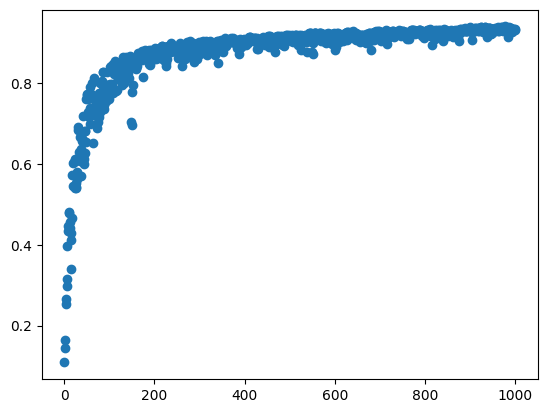

In [28]:
TOTAL_STEPS = 1000
TEST_EVERY  = 1
net2 = Network_v2(shape=[784,128,64,10])

x = [i for i in range(0,TOTAL_STEPS+1, TEST_EVERY)] 
y = [test_accuracy(net2)]


for i in range(TEST_EVERY, TOTAL_STEPS+1, TEST_EVERY):
    net2.descend(x_train=x_train,y_train=y_train,alpha=0.5,max_steps=TEST_EVERY,batch_size=32)

    y.append(test_accuracy(net2))

plt.scatter(x, y)
plt.show()

### Standardizing The Module

### Epoch Selection

### Graphing Alpha, Batch Size, etc.